Train shape: (800, 4)
Test shape : (200, 4)

LDA Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       104
           1       1.00      0.96      0.98        96

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200


LDA coefficients:
[[0.16441561 4.76485037 0.214965   0.96874546]]

LDA intercept:
[0.41394049]

Decision scores:
[ -4.26193283 -10.56645641  -5.20426813   7.29285604 -12.68607118
  -8.60818936   8.83711374   5.14130067  -3.51110586 -20.06777169]

Class probabilities:
[[9.86100876e-01 1.38991242e-02]
 [9.99974235e-01 2.57652938e-05]
 [9.94536940e-01 5.46306022e-03]
 [6.79919472e-04 9.99320081e-01]
 [9.99996906e-01 3.09391191e-06]]

Predictions:
[0 0 0 1 0]

Original shape: (200, 6)
LDA transformed shape: (200, 2)


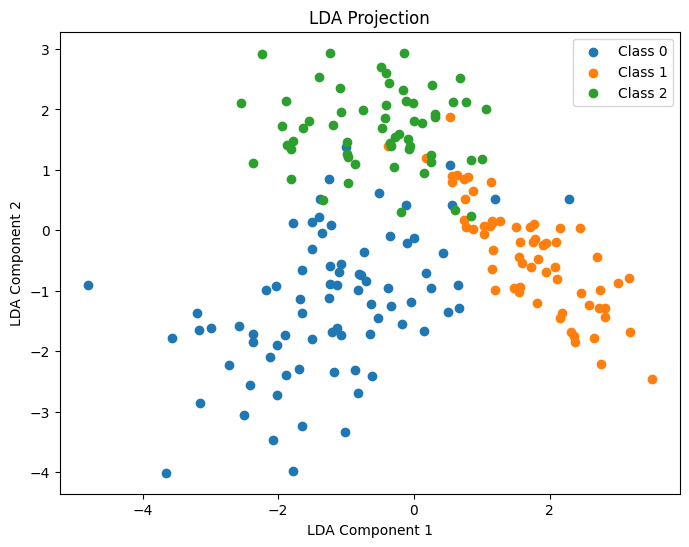


SVD Solver Accuracy: 0.98

Shrinkage LDA Accuracy: 0.975


In [1]:
# ============================================================
# LDA — LINEAR DISCRIMINANT ANALYSIS 🟡
# ============================================================
#
# DEPTH:
#   🟡 Medium
#
# No scratch implementation required.
#
# Learn:
#   1. Why LDA?
#   2. Intuition
#   3. Within-class scatter
#   4. Between-class scatter
#   5. Fisher criterion
#   6. Internal working
#   7. Probability interpretation
#   8. sklearn implementation
#   9. Important parameters
#  10. Experiments
#  11. LDA vs Logistic Regression
#  12. LDA vs QDA
#  13. Interview questions
#  14. 30-second explanation
#  15. Working tree
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


# ============================================================
# 2. WHY LDA?
# ============================================================
#
# LDA is a supervised classification algorithm.
#
# Its goal is to find a projection that makes different
# classes as separated as possible.
#
#
# Imagine:
#
# Class 0:
#
#       ● ● ●
#      ● ● ●
#
#
# Class 1:
#
#                  ○ ○ ○
#                 ○ ○ ○
#
#
# LDA finds a direction where:
#
#     points from the SAME class
#             stay close
#
#     points from DIFFERENT classes
#             become far apart
#
#
# In simple words:
#
#     Maximize between-class separation
#     Minimize within-class spread
#
# ============================================================


# ============================================================
# 3. CORE INTUITION ⭐⭐⭐
# ============================================================
#
# Suppose we have two features:
#
#     X1 = Age
#     X2 = Income
#
# And two classes:
#
#     Class 0
#     Class 1
#
#
# LDA looks for a direction:
#
#                 projection direction
#                       ↘
#                        ↘
#                         ↘
#
# such that after projecting the points onto that direction:
#
#
# Class 0:   ● ● ● ●
#
# Class 1:                     ○ ○ ○ ○
#
#
# are separated as much as possible.
#
# ============================================================


# ============================================================
# 4. WHAT DOES "LINEAR" MEAN?
# ============================================================
#
# LDA assumes that the decision boundary is linear.
#
#
# For two features:
#
#     w1*x1 + w2*x2 + b = 0
#
#
# This creates a straight-line decision boundary.
#
#
# In higher dimensions:
#
#     Hyperplane
#
# ============================================================


# ============================================================
# 5. WITHIN-CLASS SCATTER ⭐⭐⭐
# ============================================================
#
# We want points belonging to the same class to be close
# together.
#
#
# Example:
#
# Class 0:
#
#       ● ●
#      ● ● ●
#       ●
#
#
# Small spread:
#
#       GOOD
#
#
# Mathematically, LDA measures this using:
#
#     Within-Class Scatter Matrix
#
# Usually written as:
#
#     S_W
#
#
# Intuition:
#
#     S_W = how spread out each class is internally
#
# ============================================================


# ============================================================
# 6. BETWEEN-CLASS SCATTER ⭐⭐⭐
# ============================================================
#
# We also want different classes to be far apart.
#
#
# Example:
#
# Class 0:
#
#     ● ● ●
#
#
#                    ○ ○ ○
#
# Class 1:
#
#
# Large distance between class means:
#
#       GOOD
#
#
# This is represented by:
#
#     Between-Class Scatter Matrix
#
# written as:
#
#     S_B
#
#
# Intuition:
#
#     S_B = distance between class means
#
# ============================================================


# ============================================================
# 7. FISHER'S CRITERION ⭐⭐⭐
# ============================================================
#
# LDA tries to maximize:
#
#
#                 Between-Class Scatter
# J(w) = --------------------------------
#                 Within-Class Scatter
#
#
# More formally:
#
#
#          w^T S_B w
# J(w) = -----------
#          w^T S_W w
#
#
# We want:
#
#     Between-class separation ↑
#
# and:
#
#     Within-class spread ↓
#
#
# Therefore:
#
#     maximize J(w)
#
# ============================================================


# ============================================================
# 8. SIMPLE NUMERICAL INTUITION
# ============================================================
#
# Suppose we have two possible projection directions.
#
#
# Direction A:
#
#     Between-class distance = 10
#     Within-class spread    = 5
#
#
# Score:
#
#     10 / 5 = 2
#
#
# Direction B:
#
#     Between-class distance = 8
#     Within-class spread    = 2
#
#
# Score:
#
#     8 / 2 = 4
#
#
# LDA prefers Direction B.
#
#
# Why?
#
# Because classes are separated well relative to
# their internal spread.
#
# ============================================================


# ============================================================
# 9. INTERNAL WORKING
# ============================================================
#
# Training:
#
# Dataset
#    ↓
# Separate samples by class
#    ↓
# Calculate mean of each class
#    ↓
# Calculate within-class scatter S_W
#    ↓
# Calculate between-class scatter S_B
#    ↓
# Find projection direction(s)
#    ↓
# Project data
#    ↓
# Build linear discriminant classifier
#
#
# Prediction:
#
# New sample
#    ↓
# Project into discriminant space
#    ↓
# Calculate class scores / probabilities
#    ↓
# Select class
#
# ============================================================


# ============================================================
# 10. IMPORTANT MATHEMATICS
# ============================================================
#
# For class k:
#
#     Mean:
#
#     μ_k
#
#
# Within-class scatter:
#
#
#     S_W = Σ_k Σ_(x in class k)
#           (x - μ_k)(x - μ_k)^T
#
#
# Between-class scatter:
#
#
#     S_B = Σ_k n_k
#           (μ_k - μ)(μ_k - μ)^T
#
#
# where:
#
#     μ_k = mean of class k
#     μ   = overall mean
#     n_k = number of samples in class k
#
#
# LDA finds directions related to:
#
#
#     S_W^-1 S_B
#
#
# More precisely, solve the generalized eigenvalue problem:
#
#
#     S_B w = λ S_W w
#
#
# The eigenvectors give discriminant directions.
#
#
# You DON'T need to implement this from scratch for this
# medium-depth version.
#
# ============================================================


# ============================================================
# 11. NUMBER OF LDA COMPONENTS
# ============================================================
#
# If there are K classes:
#
# Maximum number of useful discriminant directions:
#
#     K - 1
#
#
# Example:
#
# 2 classes:
#
#     maximum components = 1
#
#
# 3 classes:
#
#     maximum components = 2
#
#
# 4 classes:
#
#     maximum components = 3
#
#
# Therefore:
#
#     n_components <= number_of_classes - 1
#
# ============================================================


# ============================================================
# 12. CREATE DATASET
# ============================================================

X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    class_sep=1.5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


# ============================================================
# 13. BASIC LDA CLASSIFIER
# ============================================================

lda = LinearDiscriminantAnalysis()

lda.fit(
    X_train,
    y_train
)

pred = lda.predict(
    X_test
)

print(
    "\nLDA Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        pred
    )
)


# ============================================================
# 14. LDA COEFFICIENTS
# ============================================================
#
# For a binary classification problem, LDA learns a linear
# discriminant direction.
#
# sklearn exposes:
#
#     coef_
#
# ============================================================

print("\nLDA coefficients:")

print(lda.coef_)

print("\nLDA intercept:")

print(lda.intercept_)


# ============================================================
# 15. DECISION FUNCTION
# ============================================================
#
# LDA can provide a decision score.
# ============================================================

scores = lda.decision_function(
    X_test[:10]
)

print(
    "\nDecision scores:"
)

print(scores)


# ============================================================
# 16. PREDICT PROBABILITIES
# ============================================================
#
# LDA can also estimate class probabilities.
# ============================================================

probabilities = lda.predict_proba(
    X_test[:5]
)

print(
    "\nClass probabilities:"
)

print(probabilities)

print(
    "\nPredictions:"
)

print(
    lda.predict(
        X_test[:5]
    )
)


# ============================================================
# 17. LDA AS DIMENSIONALITY REDUCTION
# ============================================================
#
# IMPORTANT:
#
# LDA can also be used to reduce dimensions.
#
# But here it is SUPERVISED dimensionality reduction.
#
# It uses class labels to find directions that separate
# classes.
#
#
# Example:
#
# Original:
#
#     10 features
#
#       ↓
#
# LDA
#
#       ↓
#
#     1 or 2 discriminant components
#
#
# PCA is different:
#
#     PCA does NOT use labels.
#
#
# LDA:
#
#     Uses labels.
#
# ============================================================


# ============================================================
# 18. LDA WITH 3 CLASSES
# ============================================================

X3, y3 = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42
)

lda3 = LinearDiscriminantAnalysis(
    n_components=2
)

lda3.fit(
    X3_train,
    y3_train
)

X3_transformed = lda3.transform(
    X3_test
)

print(
    "\nOriginal shape:",
    X3_test.shape
)

print(
    "LDA transformed shape:",
    X3_transformed.shape
)


# ============================================================
# 19. VISUALIZE LDA PROJECTION
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X3_transformed[y3_test == 0, 0],
    X3_transformed[y3_test == 0, 1],
    label="Class 0"
)

plt.scatter(
    X3_transformed[y3_test == 1, 0],
    X3_transformed[y3_test == 1, 1],
    label="Class 1"
)

plt.scatter(
    X3_transformed[y3_test == 2, 0],
    X3_transformed[y3_test == 2, 1],
    label="Class 2"
)

plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")

plt.title(
    "LDA Projection"
)

plt.legend()

plt.show()


# ============================================================
# 20. SOLVER PARAMETER ⭐⭐⭐
# ============================================================
#
# sklearn LDA supports different solvers.
#
#
# "svd"
#
#     Default.
#
#     Does not explicitly calculate the covariance matrix.
#
#     Good general-purpose choice.
#
#
# "lsqr"
#
#     Uses least-squares solution.
#
#     Can be useful with shrinkage.
#
#
# "eigen"
#
#     Uses eigenvalue decomposition.
#
#     Can also work with shrinkage.
#
# ============================================================


# ============================================================
# 21. LDA WITH SVD
# ============================================================

lda_svd = LinearDiscriminantAnalysis(
    solver="svd"
)

lda_svd.fit(
    X_train,
    y_train
)

print(
    "\nSVD Solver Accuracy:",
    accuracy_score(
        y_test,
        lda_svd.predict(X_test)
    )
)


# ============================================================
# 22. SHRINKAGE ⭐⭐
# ============================================================
#
# LDA estimates a covariance matrix.
#
# With many features and relatively few samples,
# covariance estimation can become unstable.
#
# Shrinkage can make covariance estimation more stable.
#
#
# Example:
#
# solver="lsqr"
# shrinkage="auto"
#
# ============================================================

lda_shrinkage = LinearDiscriminantAnalysis(
    solver="lsqr",
    shrinkage="auto"
)

lda_shrinkage.fit(
    X_train,
    y_train
)

print(
    "\nShrinkage LDA Accuracy:",
    accuracy_score(
        y_test,
        lda_shrinkage.predict(X_test)
    )
)


# ============================================================
# 23. IMPORTANT PARAMETERS
# ============================================================
#
#
# ------------------------------------------------------------
# solver ⭐⭐⭐
# ------------------------------------------------------------
#
# How LDA solves the optimization problem.
#
# Options:
#
#     "svd"
#     "lsqr"
#     "eigen"
#
#
# ------------------------------------------------------------
# n_components ⭐⭐⭐
# ------------------------------------------------------------
#
# Number of discriminant components.
#
# Maximum:
#
#     number_of_classes - 1
#
#
# ------------------------------------------------------------
# shrinkage
# ------------------------------------------------------------
#
# Helps stabilize covariance estimation.
#
# Options:
#
#     None
#     "auto"
#
# Mostly used with:
#
#     solver="lsqr"
#     solver="eigen"
#
#
# ------------------------------------------------------------
# priors
# ------------------------------------------------------------
#
# Prior probabilities of classes.
#
# Example:
#
# priors=[0.7, 0.3]
#
#
# ------------------------------------------------------------
# store_covariance
# ------------------------------------------------------------
#
# Whether to store covariance matrices.
#
#
# ------------------------------------------------------------
# tol
# ------------------------------------------------------------
#
# Threshold used by the SVD solver.
#
# ============================================================


# ============================================================
# 24. LDA ASSUMPTIONS ⭐⭐⭐
# ============================================================
#
# Classical LDA makes important assumptions.
#
#
# 1. Each class is approximately Gaussian.
#
#
# 2. Classes have approximately the SAME covariance matrix.
#
#
# Example:
#
# Class 0:
#
#      covariance = Σ
#
# Class 1:
#
#      covariance = Σ
#
#
# Means can differ:
#
#      μ0 != μ1
#
#
# But covariance is assumed shared.
#
#
# This is why LDA produces LINEAR decision boundaries.
#
# ============================================================


# ============================================================
# 25. LDA vs QDA ⭐⭐⭐
# ============================================================
#
# This is extremely important.
#
#
# LDA:
#
#     Shared covariance matrix
#
#     Σ0 = Σ1 = Σ
#
#     ↓
#
#     Linear decision boundary
#
#
# QDA:
#
#     Each class gets its own covariance matrix
#
#     Σ0 != Σ1
#
#     ↓
#
#     Quadratic decision boundary
#
#
# Easy memory:
#
#
# LDA:
#
#     Linear
#     Shared covariance
#
#
# QDA:
#
#     Quadratic
#     Separate covariance
#
# ============================================================


# ============================================================
# 26. LDA vs LOGISTIC REGRESSION
# ============================================================
#
# Both can produce linear decision boundaries.
#
#
# Logistic Regression:
#
#     Discriminative
#     Models P(Y | X)
#     Uses log-loss
#
#
# LDA:
#
#     Generative
#     Models:
#
#         P(X | Y)
#         P(Y)
#
#     Then applies Bayes theorem.
#
#
# LDA additionally assumes:
#
#     Gaussian class distributions
#     Shared covariance matrix
#
#
# ============================================================


# ============================================================
# 27. LDA vs NAIVE BAYES
# ============================================================
#
# Both are generative classifiers.
#
#
# Naive Bayes:
#
#     Assumes features are conditionally independent.
#
#
# LDA:
#
#     Allows correlations between features.
#
#     But assumes classes share the same covariance matrix.
#
#
# In covariance terms:
#
#
# Naive Bayes:
#
#     covariance matrix is effectively diagonal.
#
#
# LDA:
#
#     covariance matrix can contain correlations.
#
# ============================================================


# ============================================================
# 28. ADVANTAGES
# ============================================================
#
# 1. Simple and interpretable.
#
# 2. Fast to train.
#
# 3. Fast prediction.
#
# 4. Works well when assumptions are approximately true.
#
# 5. Useful for classification.
#
# 6. Can also perform supervised dimensionality reduction.
#
# 7. Often useful when classes have approximately Gaussian
#    distributions with similar covariance.
#
# ============================================================


# ============================================================
# 29. DISADVANTAGES
# ============================================================
#
# 1. Assumptions may not hold.
#
# 2. Assumes shared covariance across classes.
#
# 3. Can struggle when class boundaries are strongly nonlinear.
#
# 4. Sensitive to unusual distributions/outliers.
#
# 5. Covariance estimation can become difficult with many
#    features and few samples.
#
# ============================================================


# ============================================================
# 30. INTERVIEW QUESTIONS
# ============================================================
#
#
# Q1. What is LDA?
#
# Answer:
#
# LDA is a supervised classification algorithm that finds
# linear projections maximizing separation between classes
# while minimizing variation within each class.
#
#
# ------------------------------------------------------------
#
# Q2. What does LDA optimize?
#
# Answer:
#
# It maximizes the ratio of between-class scatter to
# within-class scatter.
#
#
#       w^T S_B w
#       ----------
#       w^T S_W w
#
#
# ------------------------------------------------------------
#
# Q3. What is within-class scatter?
#
# Answer:
#
# It measures how spread out samples are within each class.
#
#
# ------------------------------------------------------------
#
# Q4. What is between-class scatter?
#
# Answer:
#
# It measures how separated the class means are.
#
#
# ------------------------------------------------------------
#
# Q5. Why is LDA linear?
#
# Answer:
#
# Classical LDA assumes all classes share the same covariance
# matrix, which results in a linear discriminant boundary.
#
#
# ------------------------------------------------------------
#
# Q6. LDA vs QDA?
#
# Answer:
#
# LDA assumes a shared covariance matrix and produces linear
# boundaries. QDA estimates a separate covariance matrix for
# each class and can produce quadratic boundaries.
#
#
# ------------------------------------------------------------
#
# Q7. LDA vs Logistic Regression?
#
# Answer:
#
# Logistic Regression is discriminative and directly models
# P(Y|X), while LDA is generative and models P(X|Y) and
# P(Y) under Gaussian/shared-covariance assumptions.
#
#
# ------------------------------------------------------------
#
# Q8. How many LDA components can we have?
#
# Answer:
#
# At most:
#
#     number of classes - 1
#
#
# ------------------------------------------------------------
#
# Q9. Is LDA supervised or unsupervised?
#
# Answer:
#
# Supervised, because it uses class labels to find
# discriminant directions.
#
#
# ------------------------------------------------------------
#
# Q10. Can LDA be used for dimensionality reduction?
#
# Answer:
#
# Yes. LDA can project data into at most K-1 dimensions,
# where K is the number of classes, while trying to preserve
# class separation.
#
#
# ============================================================


# ============================================================
# 31. 30-SECOND INTERVIEW EXPLANATION ⭐⭐⭐
# ============================================================
#
# LDA is a supervised generative classification algorithm.
# It finds directions that maximize between-class separation
# relative to within-class variation.
#
# Classical LDA assumes that classes are approximately
# Gaussian and share the same covariance matrix, which leads
# to a linear decision boundary.
#
# It can also be used for supervised dimensionality reduction,
# with at most K-1 discriminant components for K classes.
#
# ============================================================


# ============================================================
# 32. FINAL MEMORY CHEATSHEET
# ============================================================
#
# LDA =
#
# Between-Class Separation
#          ↑
#          |
#          |
#     ----------------
#     Within-Class Spread
#
#
# CORE IDEA:
#
#     Maximize:
#
#     Between-class scatter
#     ---------------------
#     Within-class scatter
#
#
# MUST REMEMBER:
#
# 1. LDA = Linear Discriminant Analysis
#
# 2. Supervised algorithm
#
# 3. Classification algorithm
#
# 4. Uses class labels
#
# 5. Within-class scatter → S_W
#
# 6. Between-class scatter → S_B
#
# 7. Fisher criterion:
#
#       w^T S_B w
#       ----------
#       w^T S_W w
#
# 8. Shared covariance between classes
#
# 9. Linear decision boundary
#
# 10. Maximum components = K - 1
#
# 11. Can also perform supervised dimensionality reduction
#
# ============================================================


# ============================================================
# 33. WORKING TREE ⭐⭐⭐
# ============================================================
#
#
#                         LDA
#                          │
#                          ▼
#                    Training Data
#                          │
#                          ▼
#                    Class Labels
#                          │
#                          ▼
#                Calculate Class Means
#                          │
#              ┌───────────┴───────────┐
#              │                       │
#              ▼                       ▼
#       Within-Class Scatter     Between-Class Scatter
#              │                       │
#              │                       │
#             S_W                     S_B
#              │                       │
#              └───────────┬───────────┘
#                          │
#                          ▼
#                 Fisher Criterion
#                          │
#                          ▼
#              Maximize Between / Within
#                          │
#                          ▼
#              Find Discriminant Directions
#                          │
#                          ▼
#                  Project Data
#                          │
#                          ▼
#                 Linear Classification
#                          │
#                          ▼
#                     Prediction
#
#
# ============================================================
#
# LDA vs QDA TREE:
#
#
#                    Discriminant Analysis
#                           │
#                 ┌─────────┴─────────┐
#                 │                   │
#                 ▼                   ▼
#                LDA                 QDA
#                 │                   │
#                 ▼                   ▼
#        Shared covariance     Separate covariance
#                 │                   │
#                 ▼                   ▼
#          Linear boundary     Quadratic boundary
#
#
# ============================================================
#
# LDA DIMENSIONALITY REDUCTION:
#
#                  Data
#                   │
#                   ▼
#                Labels
#                   │
#                   ▼
#         Find class-separating directions
#                   │
#                   ▼
#              LDA Projection
#                   │
#                   ▼
#              K - 1 maximum
#             dimensions
#
#
# ============================================================
#
# ONE-LINE MENTAL MODEL:
#
#     Find the direction where:
#
#     Classes are FAR APART
#             +
#     Points within each class are CLOSE TOGETHER
#
# ============================================================